# GW Data Batch Preprocessing for BayesWave Testing

This notebook generates multiple frame configurations with different durations and amplitude factors to test BayesWave signal detection capabilities.

In [1]:
import os
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from gwpy.timeseries import TimeSeries

sns.set(style="whitegrid", context="paper", font_scale=1.8)

# Detector configuration
DETECTORS = {
    'H1': {
        'channel_name': 'H1:GW-H',
        't0_gps': 1126259462.423,
        'F_plus': 0.578742411175002,
        'F_cross': -0.45094782109531206,
        'color': 'blue'
    },
    'L1': {
        'channel_name': 'L1:GW-L',
        't0_gps': 1126259462.4160156,
        'F_plus': -0.5274334329518102,
        'F_cross': 0.20520960891727422,
        'color': 'orange'
    }
}

/home/x-ctirapongpra/.local/lib/python3.9/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


## Batch Processing Configuration

In [2]:
# Configuration matrix for bayeswave testing
DURATIONS = [4.0, 8.0, 16.0, 32.0]  # seconds - total duration after padding
AMPLIFY_FACTORS = [1.25, 0.62, 0.31]  # factors to attenuate the signal

# Processing parameters
scale_factor = 1e-23
target_sample_rate = 4096  # Hz
taper_duration = 0.5  # seconds - fixed taper duration per LIGO paper (arxiv:1908.11170)

# Output configuration
output_base_dir = '../Frames_1000'  # Base directory for outputs

# PSD parameters
psd_fftlength = 4
psd_overlap = 2

print(f"Batch configuration:")
print(f"  Durations: {DURATIONS}")
print(f"  Amplitude factors: {AMPLIFY_FACTORS}")
print(f"  Taper duration: {taper_duration}s (fixed)")
print(f"  Total configurations: {len(DURATIONS) * len(AMPLIFY_FACTORS)} per detector")
print(f"  Output directory: {output_base_dir}")

Batch configuration:
  Durations: [4.0, 8.0, 16.0, 32.0]
  Amplitude factors: [1.25, 0.62, 0.31]
  Taper duration: 0.5s (fixed)
  Total configurations: 12 per detector
  Output directory: ../Frames_1000


**Load Raw Strain Data:** Load the raw time-domain strain data and create TimeSeries objects for each detector.

In [3]:
# Load raw strain data
data_dir = '/home/x-ctirapongpra/scratch/gw-collapsar/h(t)'

# Load raw data files
time_data = np.loadtxt(os.path.join(data_dir, 't.txt'), delimiter=',')
hp_x = np.loadtxt(os.path.join(data_dir, 'hp_x.txt'))
hx_x = np.loadtxt(os.path.join(data_dir, 'hx_x.txt'))

# Calculate sample rate
dt = time_data[1] - time_data[0]
sample_rate = 1.0 / dt

# Create TimeSeries for each detector
timeseries_dict = {}
for det_name, det_params in DETECTORS.items():
    # Combine polarizations: h = F+ * hp_x + Fx * hx_x
    h_strain = det_params['F_plus'] * hp_x + det_params['F_cross'] * hx_x
    
    # Calculate duration and center time
    n_samples = len(h_strain)
    duration = (n_samples - 1) * dt
    t_start = det_params['t0_gps'] - duration / 2.0
    
    # Create TimeSeries
    timeseries_dict[det_name] = TimeSeries(
        h_strain,
        sample_rate=sample_rate,
        t0=t_start,
        name=det_params['channel_name'],
        unit='strain'
    )

print(f"Loaded {len(timeseries_dict)} detectors")
print(f"Sample rate: {sample_rate:.2f} Hz")
for det_name, ts in timeseries_dict.items():
    print(f"{det_name}:")
    print(f"  Duration: {ts.duration.value:.3f} s")
    print(f"  Samples: {len(ts)}")
    print(f"  t0: {ts.t0.value:.6f} GPS")

Loaded 2 detectors
Sample rate: 10000.00 Hz
H1:
  Duration: 24.000 s
  Samples: 240000
  t0: 1126259450.423050 GPS
L1:
  Duration: 24.000 s
  Samples: 240000
  t0: 1126259450.416066 GPS


## Batch Processing Loop

Process all configurations in nested loops:
- Outer loop: duration configurations (4s, 8s, 16s, 32s)
- Inner loop: amplitude factors (1.25, 0.62, 0.31)

For each configuration:
1. Scale and crop proportionally
2. Resample to 4096 Hz
3. Apply Tukey taper with **fixed 0.5s transition regions** (per LIGO paper arxiv:1908.11170)
   - Alpha is calculated dynamically: `alpha = 2 * (0.5s * sample_rate) / n_samples`
   - Taper applied BEFORE padding so it affects actual signal, not zeros
4. Pad to target duration with zeros
5. Export GWF files
6. Calculate and export PSDs

In [4]:
# Store all configurations for visualization
all_configs = []

for target_duration in DURATIONS:
    for amplify_factor in AMPLIFY_FACTORS:
        # Calculate proportional crop duration
        crop_duration = target_duration / 2.0
        
        # Create output directory
        output_dir = f"{output_base_dir}/dur_{int(target_duration):02d}s_amp_{amplify_factor:.2f}"
        os.makedirs(output_dir, exist_ok=True)
        
        print(f"Processing: duration={target_duration}s, amplitude={amplify_factor}, crop={crop_duration}s")
        print(f"Output: {output_dir}")
        
        # Process each detector
        ts_cropped = {}
        ts_resampled = {}
        ts_tapered = {}
        ts_padded = {}
        psd_dict = {}
        
        for det_name, ts in timeseries_dict.items():
            t0_gps = DETECTORS[det_name]['t0_gps']
            
            # 1. Scale and crop (symmetric around t0_gps)
            ts_scaled = ts * scale_factor * amplify_factor
            ts_cropped[det_name] = ts_scaled.crop(t0_gps - crop_duration/2, t0_gps + crop_duration/2)
            
            # 2. Resample to 4096 Hz
            ts_resampled[det_name] = ts_cropped[det_name].resample(target_sample_rate)
            
            # 3. Apply Tukey taper BEFORE padding (to taper actual signal, not zeros)
            # Calculate alpha from fixed taper duration (0.5s per LIGO paper)
            # alpha = 2 * taper_samples / total_samples (factor of 2 because alpha spans both edges)
            n_samples = len(ts_resampled[det_name])
            taper_samples = taper_duration * target_sample_rate
            tukey_alpha = min(2.0 * taper_samples / n_samples, 1.0)  # cap at 1.0
            
            tukey_window = signal.windows.tukey(n_samples, alpha=tukey_alpha)
            ts_tapered[det_name] = ts_resampled[det_name] * tukey_window
            
            print(f"  {det_name}: n_samples={n_samples}, taper_samples={taper_samples:.0f}, alpha={tukey_alpha:.3f}")
            
            # 4. Pad to target duration
            target_samples = int(target_duration * target_sample_rate)
            current_samples = len(ts_tapered[det_name])
            
            if current_samples < target_samples:
                # Calculate total padding needed
                total_padding_samples = target_samples - current_samples
                
                # Split padding symmetrically
                pad_left = total_padding_samples // 2
                pad_right = total_padding_samples - pad_left
                
                # Pad symmetrically
                ts_temp = ts_tapered[det_name].pad((pad_left, pad_right))
                
                # Shift to start frame at integer GPS time
                t0_int = t0_gps  # Floor to integer GPS second
                desired_t0 = t0_int - (target_duration / 2.0)
                shift_amount = desired_t0 - ts_temp.t0.value
                ts_temp.shift(shift_amount)
                ts_padded[det_name] = ts_temp
            else:
                ts_padded[det_name] = ts_tapered[det_name]
            
            print(f"    Final: {ts_padded[det_name].duration.value:.1f}s, {len(ts_padded[det_name])} samples")
        
        # 5. Export GWF files
        for det_name, ts in ts_padded.items():
            filename = os.path.join(output_dir, f'{det_name}.gwf')
            ts.write(filename, format='gwf')
            print(f"  Written: {filename}")
        
        # 6. Calculate and export PSDs
        for det_name, ts in ts_padded.items():
            psd = ts.psd(fftlength=psd_fftlength, overlap=psd_overlap, method='median')
            psd_dict[det_name] = psd
            
            # Remove Nyquist frequency for BayesWave compatibility
            psd_truncated = psd[:-1]
            
            filename = os.path.join(output_dir, f'{det_name}_psd.dat')
            np.savetxt(
                filename,
                np.column_stack([psd_truncated.frequencies.value, psd_truncated.value]),
                delimiter=' '
            )
            print(f"  Written: {filename}")
        
        # Store configuration for visualization
        all_configs.append({
            'ts_tapered': copy.deepcopy(ts_tapered),
            'ts_padded': copy.deepcopy(ts_padded),
            'psd_dict': copy.deepcopy(psd_dict),
            'duration': target_duration,
            'amplitude': amplify_factor
        })

print("\n" + "="*70)
print("Batch processing complete!")
print(f"Generated {len(DURATIONS) * len(AMPLIFY_FACTORS)} configurations for each detector")

Processing: duration=4.0s, amplitude=1.25, crop=2.0s
Output: ../Frames_1000/dur_04s_amp_1.25
  H1: n_samples=8192, taper_samples=2048, alpha=0.500
    Final: 4.0s, 16384 samples
  L1: n_samples=8192, taper_samples=2048, alpha=0.500
    Final: 4.0s, 16384 samples
  Written: ../Frames_1000/dur_04s_amp_1.25/H1.gwf
  Written: ../Frames_1000/dur_04s_amp_1.25/L1.gwf


  Written: ../Frames_1000/dur_04s_amp_1.25/H1_psd.dat
  Written: ../Frames_1000/dur_04s_amp_1.25/L1_psd.dat
Processing: duration=4.0s, amplitude=0.62, crop=2.0s
Output: ../Frames_1000/dur_04s_amp_0.62
  H1: n_samples=8192, taper_samples=2048, alpha=0.500
    Final: 4.0s, 16384 samples
  L1: n_samples=8192, taper_samples=2048, alpha=0.500
    Final: 4.0s, 16384 samples
  Written: ../Frames_1000/dur_04s_amp_0.62/H1.gwf
  Written: ../Frames_1000/dur_04s_amp_0.62/L1.gwf
  Written: ../Frames_1000/dur_04s_amp_0.62/H1_psd.dat
  Written: ../Frames_1000/dur_04s_amp_0.62/L1_psd.dat
Processing: duration=4.0s, amplitude=0.31, crop=2.0s
Output: ../Frames_1000/dur_04s_amp_0.31
  H1: n_samples=8192, taper_samples=2048, alpha=0.500
    Final: 4.0s, 16384 samples
  L1: n_samples=8192, taper_samples=2048, alpha=0.500
    Final: 4.0s, 16384 samples
  Written: ../Frames_1000/dur_04s_amp_0.31/H1.gwf
  Written: ../Frames_1000/dur_04s_amp_0.31/L1.gwf
  Written: ../Frames_1000/dur_04s_amp_0.31/H1_psd.dat
  Wr

## Visualization

Plot all configurations to verify the processing pipeline.

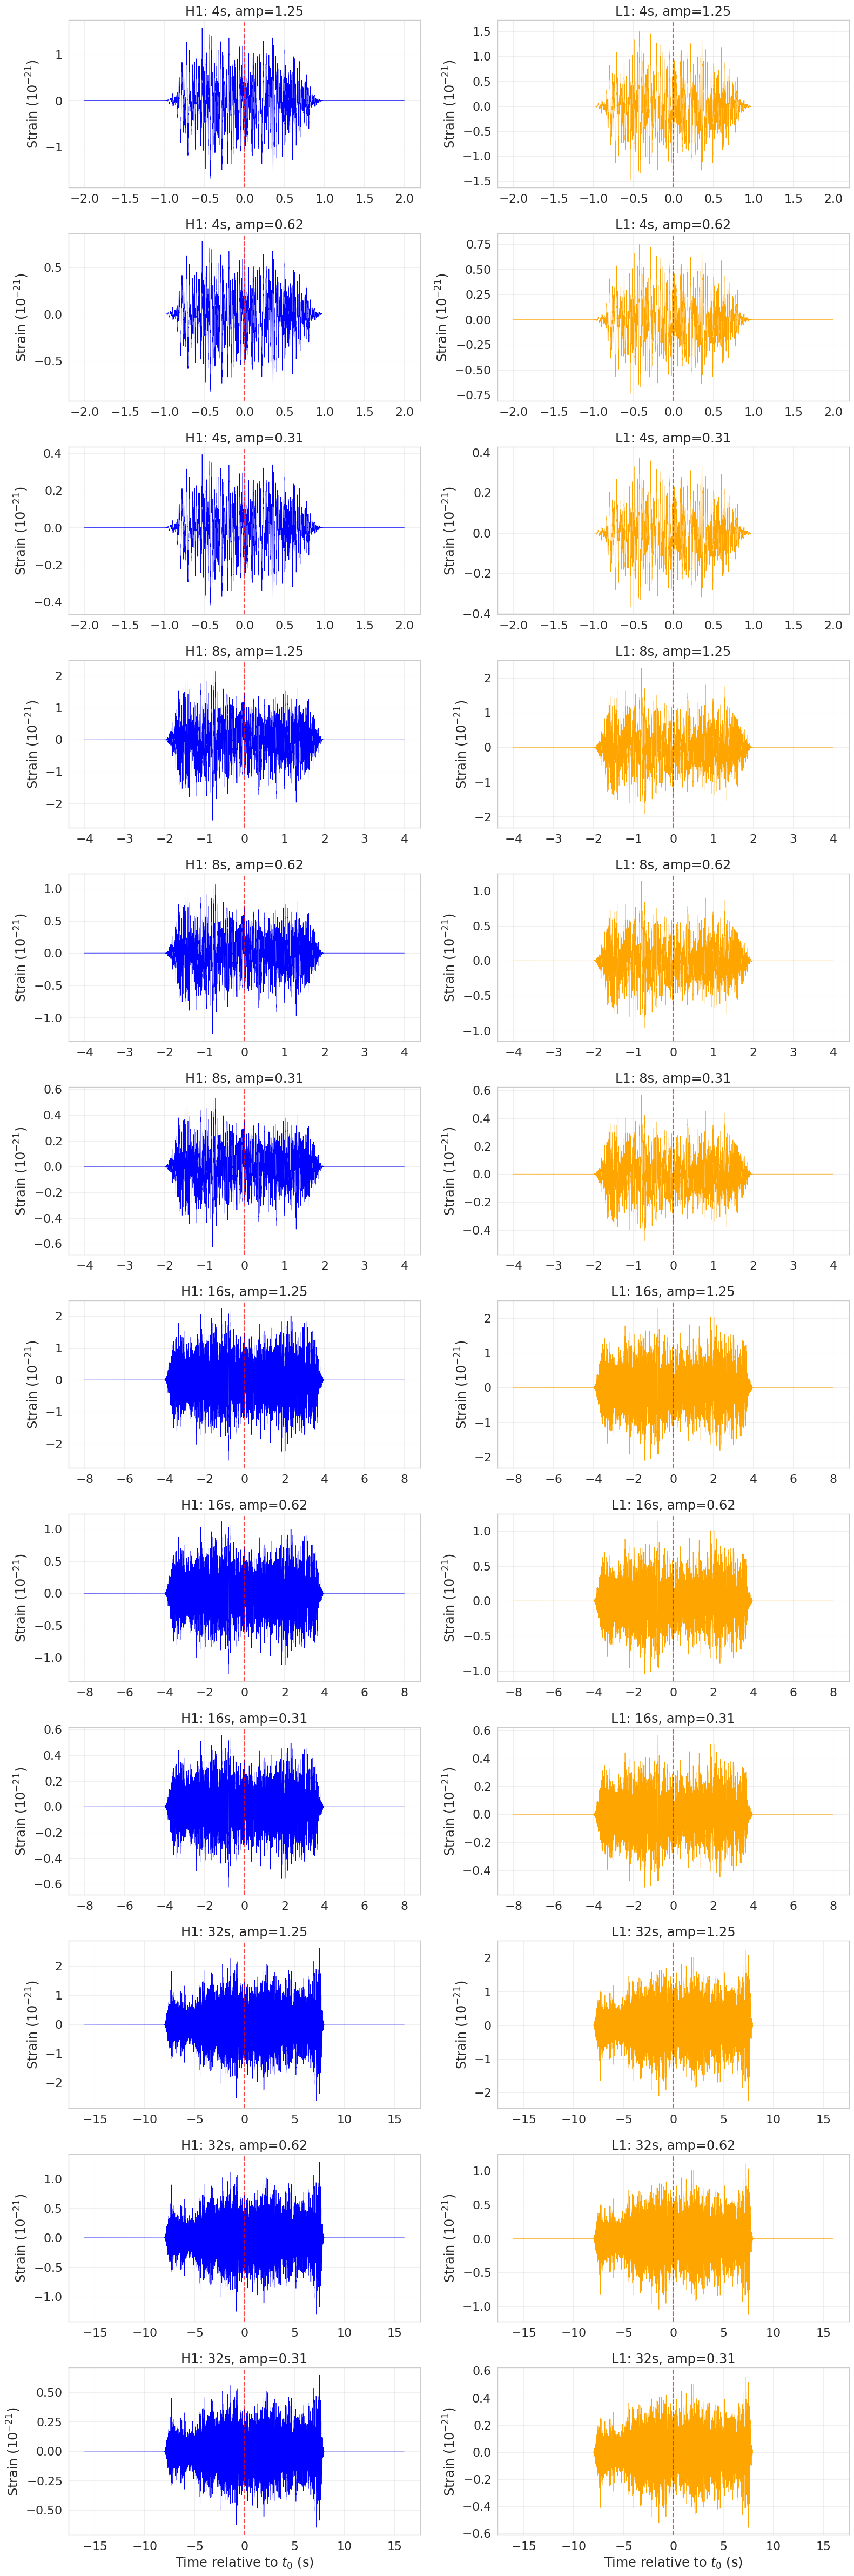

In [5]:
# Plot all configurations
if all_configs:
    n_configs = len(all_configs)
    fig, axes = plt.subplots(n_configs, 2, figsize=(16, 4 * n_configs))
    
    for config_idx, config in enumerate(all_configs):
        for det_idx, det_name in enumerate(config['ts_padded'].keys()):
            t0_gps = DETECTORS[det_name]['t0_gps']
            color = DETECTORS[det_name]['color']
            
            ax = axes[config_idx, det_idx]
            time_rel = config['ts_padded'][det_name].times.value - t0_gps
            ax.plot(time_rel, config['ts_padded'][det_name].value / 1e-21, 
                    linewidth=0.5, color=color)
            ax.set_title(f"{det_name}: {config['duration']:.0f}s, amp={config['amplitude']}")
            ax.set_ylabel('Strain ($10^{-21}$)')
            ax.grid(True, alpha=0.3)
            ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
            
            if config_idx == n_configs - 1:
                ax.set_xlabel('Time relative to $t_0$ (s)')
    
    plt.tight_layout()
    plt.show()
else:
    print("No configurations to visualize")

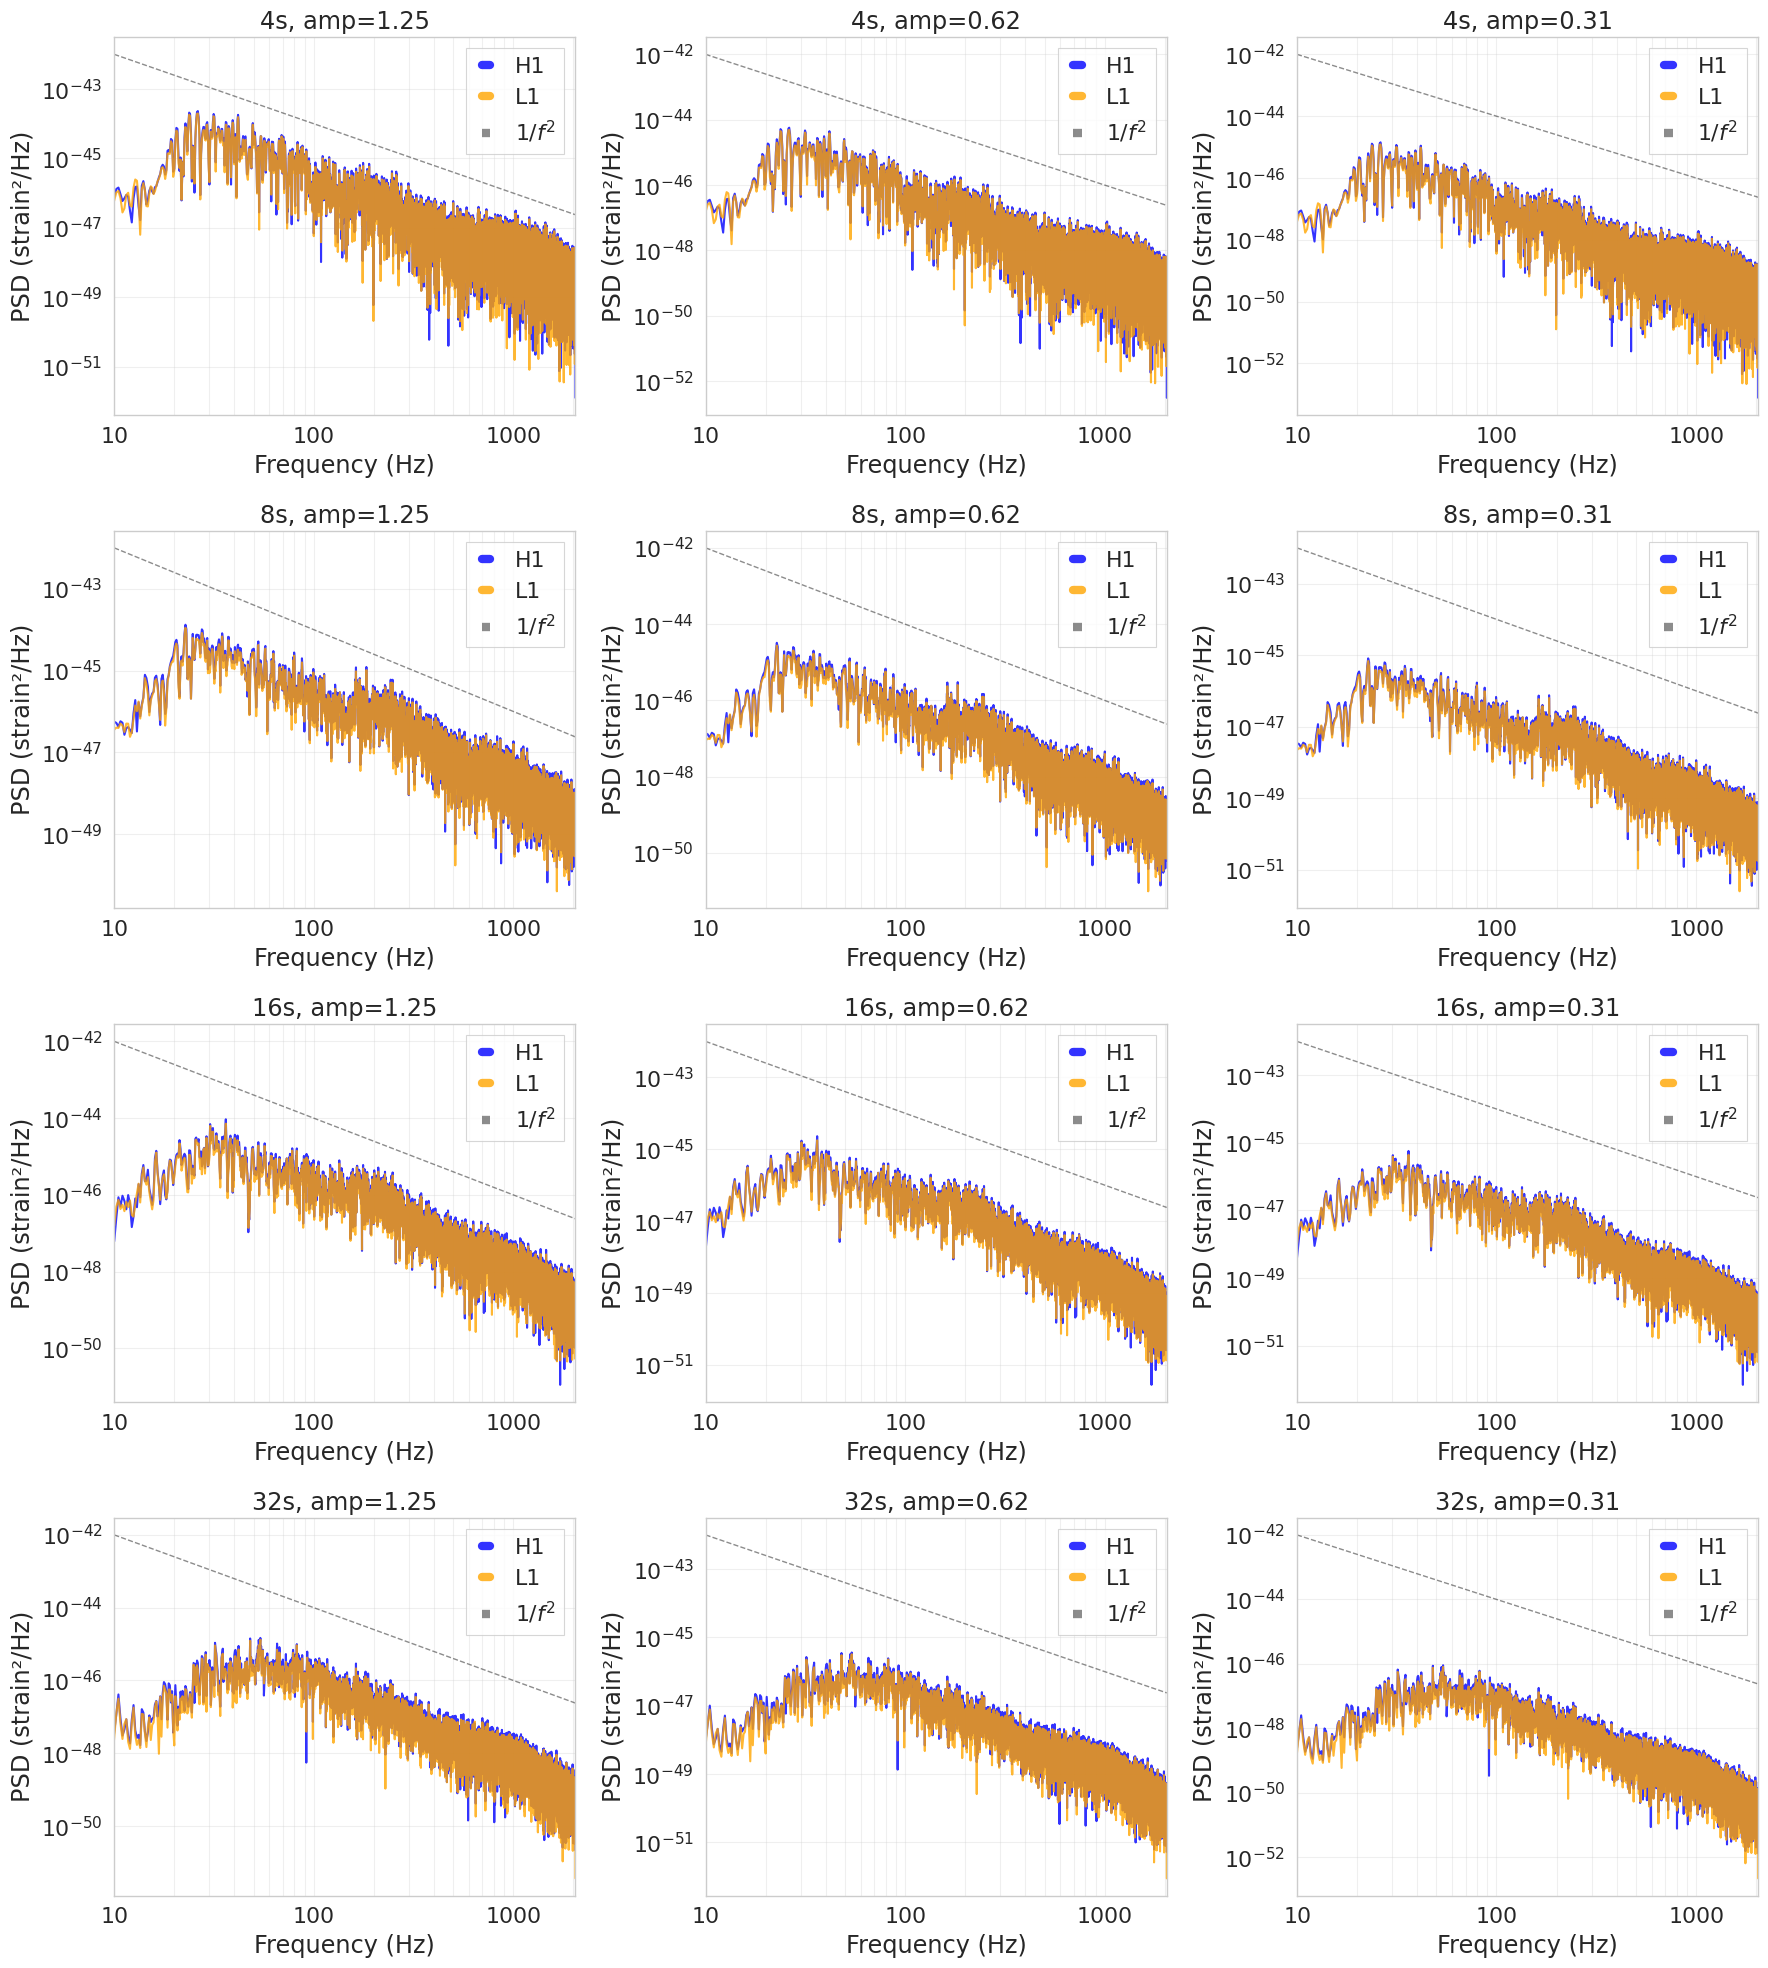

In [6]:
# Visualize PSDs of all configurations
if all_configs:
    n_configs = len(all_configs)
    n_cols = 3
    n_rows = (n_configs + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
    axes = axes.flatten()
    
    for config_idx, config in enumerate(all_configs):
        ax = axes[config_idx]
        
        for det_name, psd in config['psd_dict'].items():
            ax.loglog(psd.frequencies.value, psd.value,
                      color=DETECTORS[det_name]['color'], linewidth=1.5, 
                      label=det_name, alpha=0.8)
        
        # Add 1/f^2 reference line
        # Get frequency range from the first PSD
        first_psd = list(config['psd_dict'].values())[0]
        freq = first_psd.frequencies.value
        freq_mask = (freq >= 10) & (freq <= 2048)
        freq_plot = freq[freq_mask]
        
        # Calculate 1/f^2 and scale to match typical PSD values for visibility
        # Scale factor chosen to make the line visible in the plot
        f0 = 100  # reference frequency (Hz)
        psd0 = 1e-44  # scale factor (adjust as needed for visibility)
        one_over_f2 = psd0 * (f0 / freq_plot)**2
        
        ax.loglog(freq_plot, one_over_f2, 'k--', linewidth=1.0, 
                  label='$1/f^2$', alpha=0.5)
        
        ax.set_xlabel('Frequency (Hz)')
        ax.set_ylabel('PSD (strain²/Hz)')
        ax.set_title(f"{config['duration']:.0f}s, amp={config['amplitude']}")
        ax.set_xlim(10, 2048)
        ax.legend()
        ax.grid(True, alpha=0.3, which='both')
    
    # Hide unused subplots
    for idx in range(n_configs, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()
else:
    print("No configurations to visualize")